# Modelo DBSCAN

In [17]:
# Aquí de desarrollará el código para el modelo de DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset df_dqi_final
df_dqi_final = pd.read_csv('./Data/Processed/df_dqi_final.csv', delimiter=';')
# Cargamos el dataset df_clustering_pca
df_clustering_pca = pd.read_csv('./Data/Processed/df_clustering_pca.csv', sep=';')


Se analizan las características del dataset **df_dqi_final**

In [18]:
# Visualizamos los primeros registros de df_dqi_final
df_dqi_final.head()


,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False


In [19]:
# Visualizamos los primeros registros de df_clustering_pca
df_clustering_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,-0.587293,0.125022,-0.543732,-0.418945,-0.106454,0.091643,0.153976,-0.040388,-0.170410,-0.033183,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.966491,-0.308382,-0.146686,0.387938,0.094965,-0.106768,-0.435480,-0.128759,-0.040712,0.060743,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.005097,-0.165171,-0.351644,0.415040,0.381133,-0.065105,0.277553,-0.178965,-0.341074,0.049772,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.021594,-0.846509,0.239007,0.355802,-0.419847,0.026901,-0.163077,-0.384440,-0.336354,-0.020544,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.336719,-0.256966,0.016915,0.060767,0.091697,-0.281555,0.447879,-0.206277,-0.180261,-0.109531,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
# shape del dataset df_dqi_final y df_clustering_pca
df_dqi_final.shape, df_clustering_pca.shape

((638, 37), (638, 20))

In [21]:
df_dqi_final.describe()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,...,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,resultado_general_entrevista
count,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,...,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,6.380000e+02,638.0
mean,0.796238,0.112853,0.909091,1.147335,1.034483,0.893417,4.123824,5.943574,13.142633,9.987461,...,3.186520,4.805643,3.172414,2.952978,3.873041,24.255486,51.810345,39.985893,1.115890e+05,1.0
std,1.574677,0.513361,1.616597,1.977166,1.723073,1.678543,2.525604,0.472092,5.060392,4.200602,...,1.633059,0.592867,1.476681,1.712723,1.631093,8.509977,12.880324,13.303537,1.340553e+05,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,19.000000,18.000000,7.032174e+03,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,9.000000,6.000000,...,2.000000,5.000000,2.000000,1.000000,3.000000,18.000000,42.000000,28.000000,3.160034e+04,1.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,6.000000,12.000000,12.000000,...,3.000000,5.000000,3.000000,3.000000,5.000000,25.000000,53.000000,40.000000,6.486087e+04,1.0
75%,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,6.000000,6.000000,15.000000,12.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,61.000000,51.000000,1.352364e+05,1.0
max,6.000000,4.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,30.000000,15.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,40.000000,84.000000,64.000000,1.145273e+06,1.0


In [22]:
# cantidad de variables numericas y categoricas del dataset df_dqi_final
df_dqi_final.dtypes.value_counts()

int64      24
bool       10
object      2
float64     1
Name: count, dtype: int64

In [23]:
# cantidad de variables numericas y categoricas del dataset df_clustering_pca
df_clustering_pca.dtypes.value_counts()

float64    20
Name: count, dtype: int64

In [24]:
# Lista de columnas en df_dqi_final
df_dqi_final.columns

Index(['folio_integrante', 'macronutrients_dqi', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi',
       'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi',
       'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi',
       'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains',
       'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium',
       'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy',
       'dqi_total', 'edad', 'ponderador', 'grupo',
       'resultado_general_entrevista', 'region_Centro', 'region_Centro Norte',
       'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')

In [25]:
# Lista de columnas en df_clustering_pca
df_clustering_pca.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'region_Centro', 'region_Centro Norte', 'region_Frontera',
       'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')

# Entenamiento del modelo

Nos aseguramos en el código anterior de que no exitan datos nulos

In [26]:
# Revisando valores nulos en el dataset
null_counts = df_clustering_pca.isnull().sum()
#print(null_counts)

if null_counts.sum() > 0:
    print("Se encontraron datos nulos en el dataset.")
else:
    print("No se encontraron datos nulos en el dataset.")

No se encontraron datos nulos en el dataset.


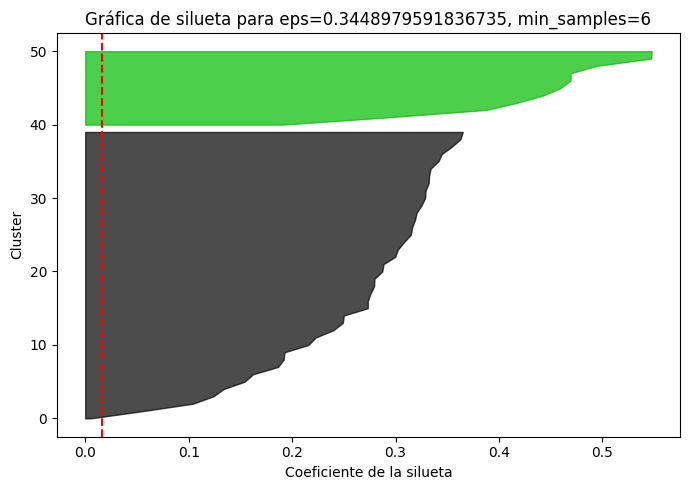

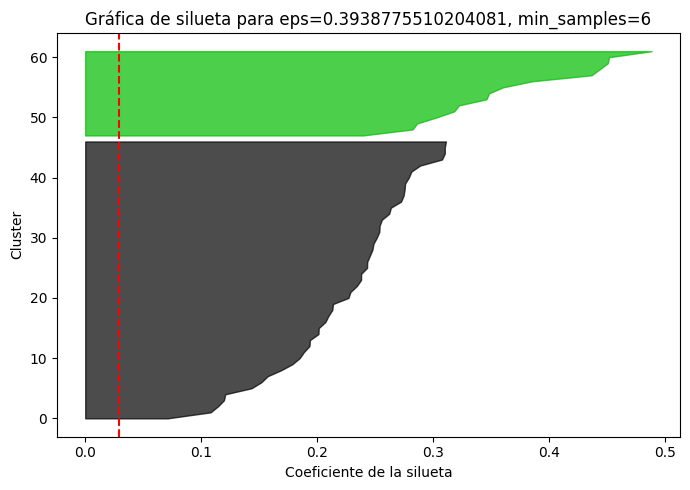

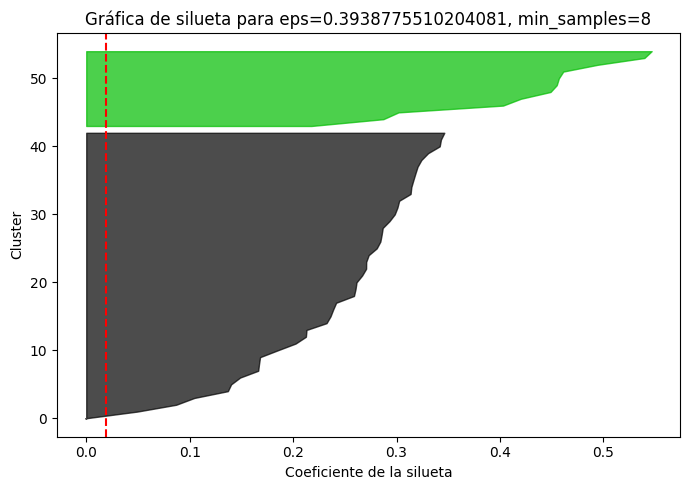

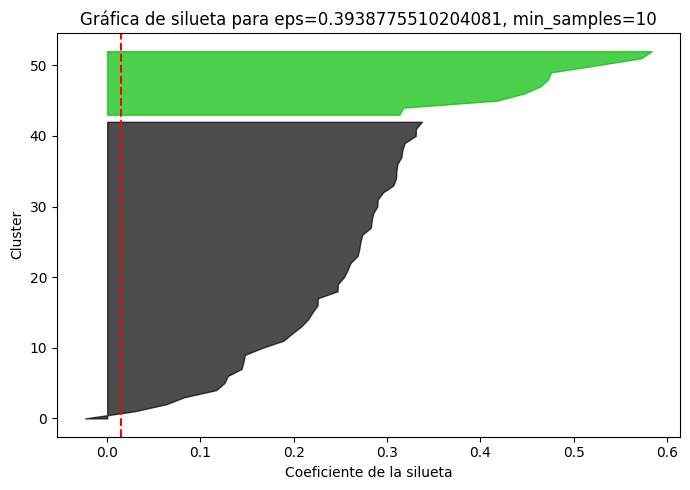

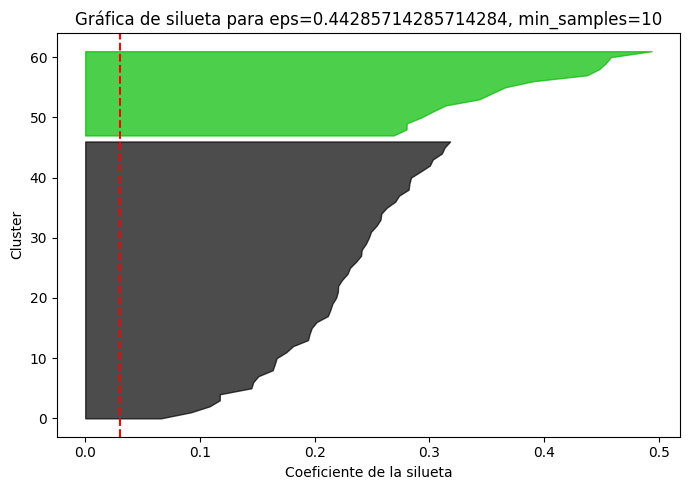

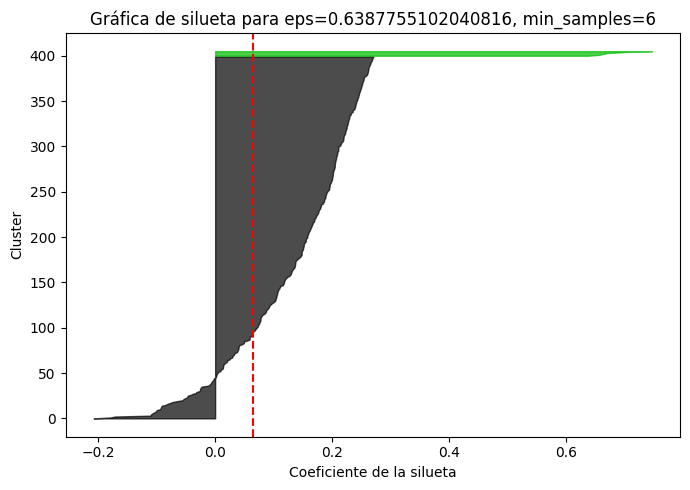

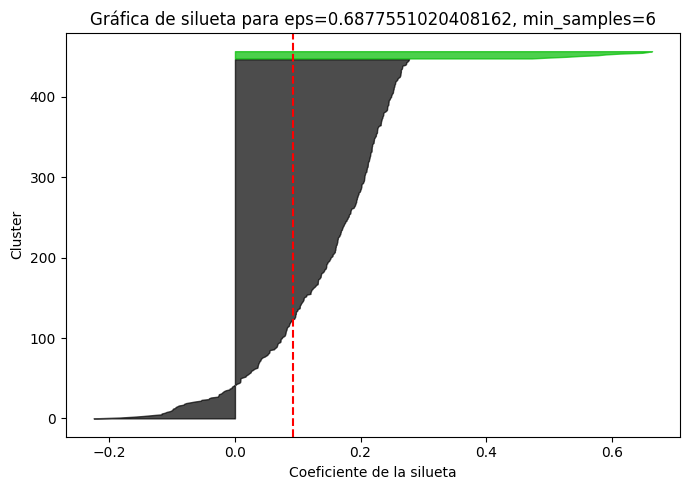

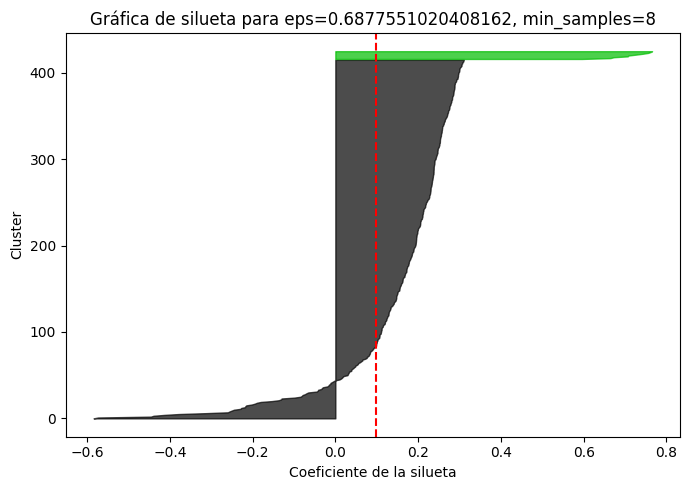

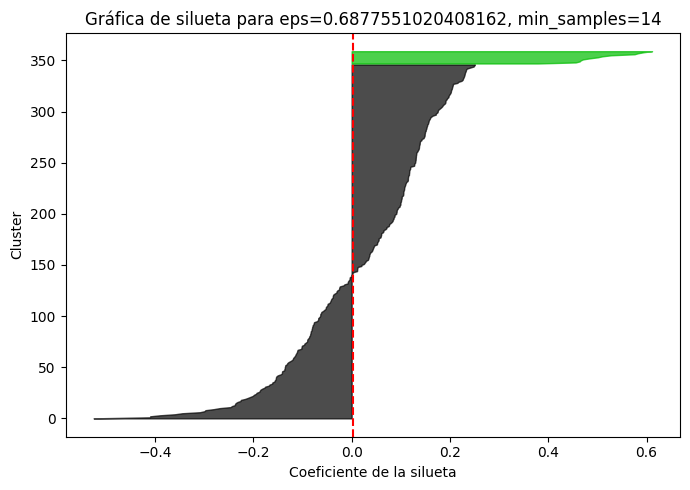

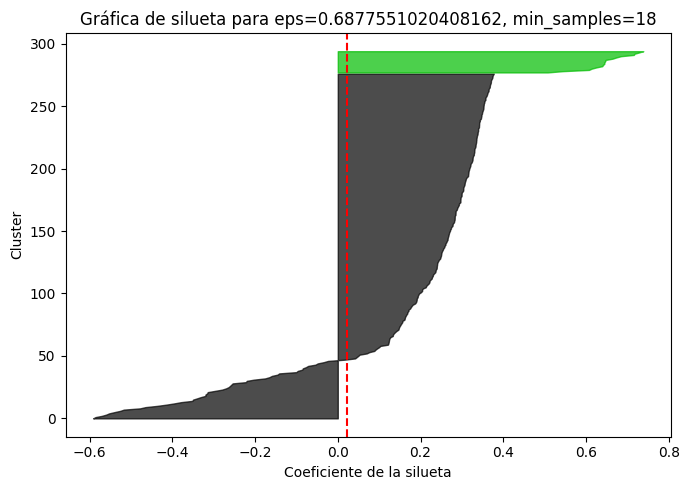

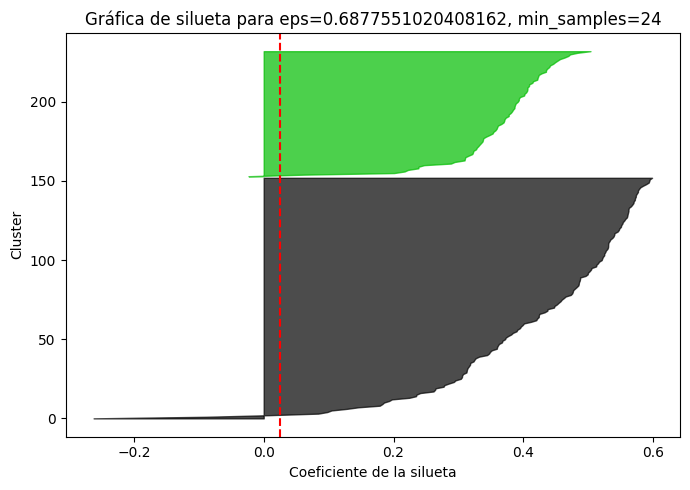

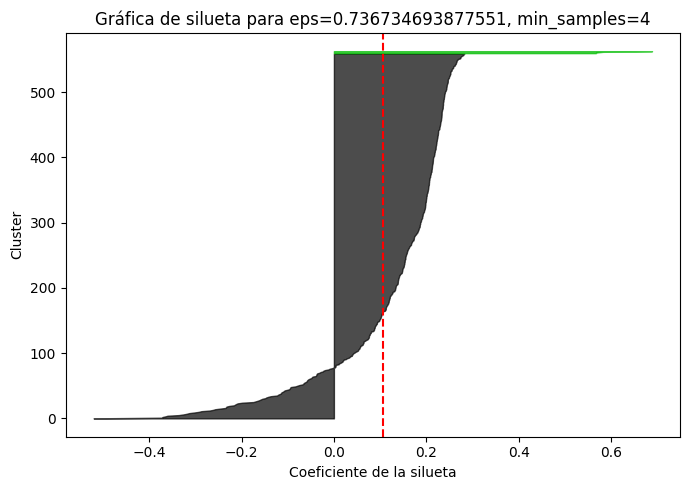

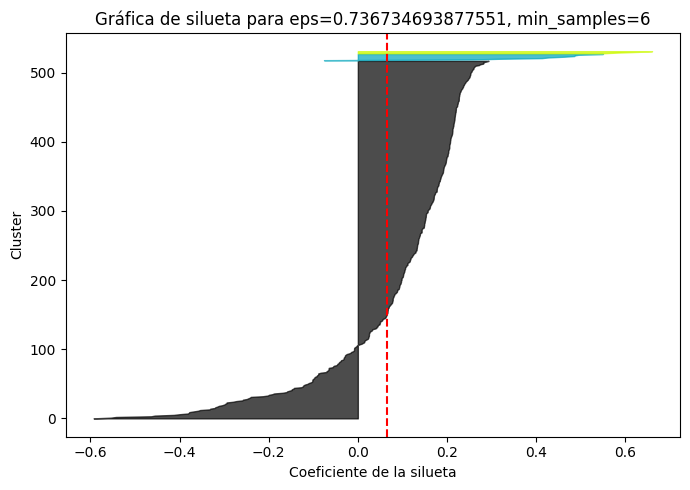

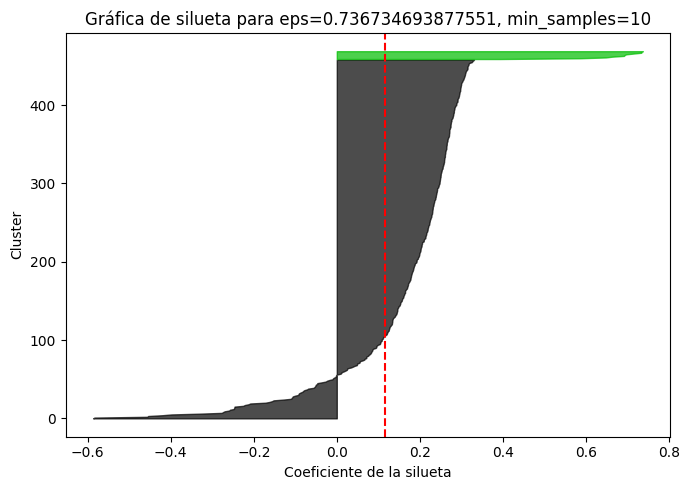

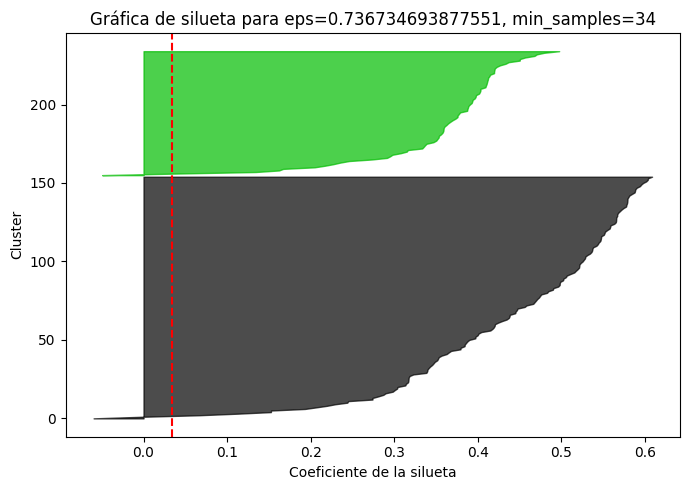

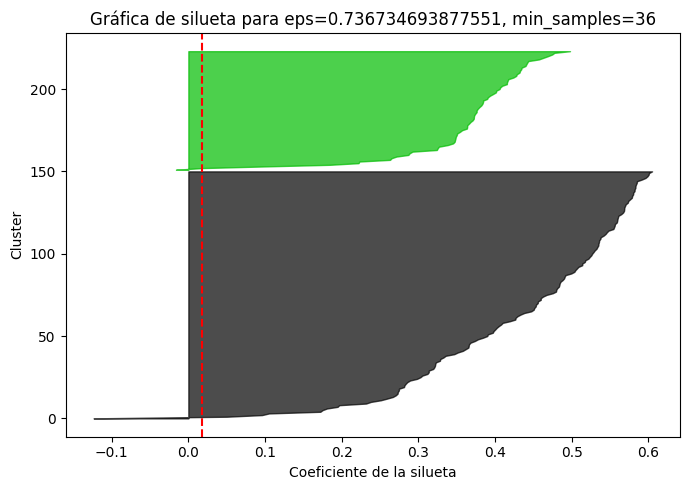

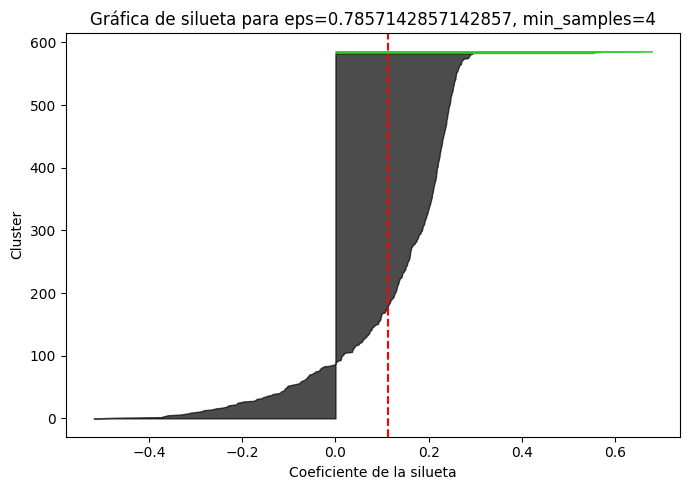

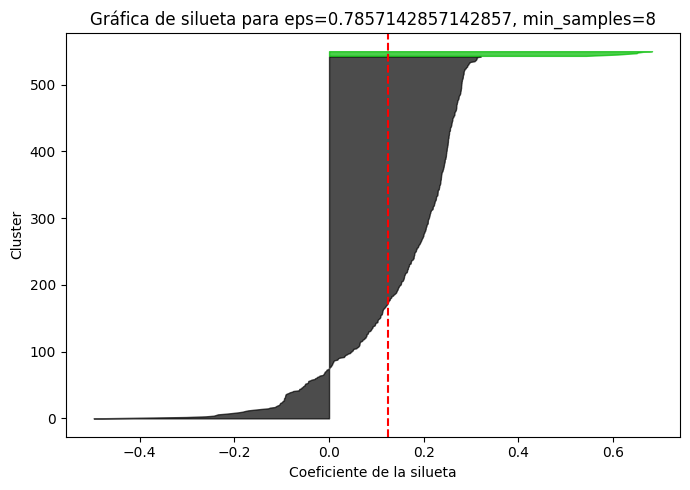

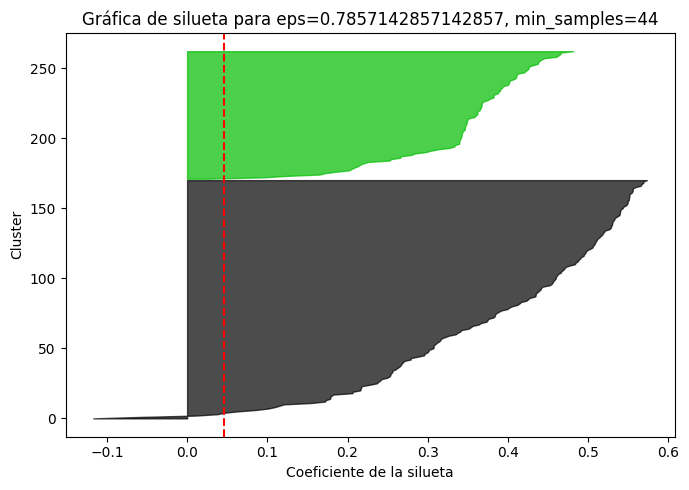

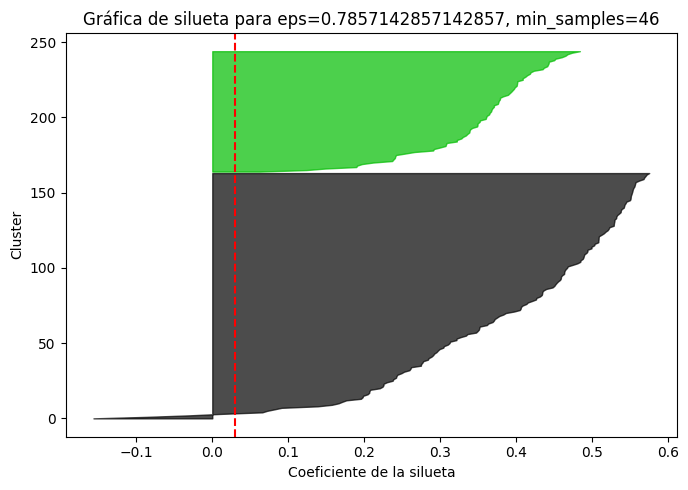

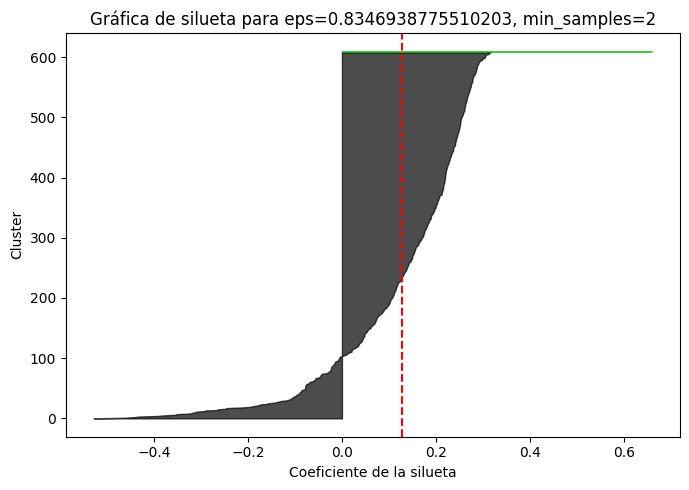

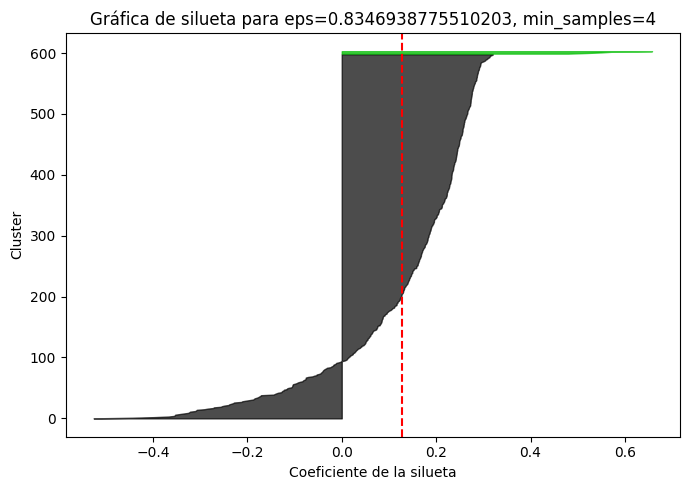

Mejor configuración DBSCAN: eps = 0.8346938775510203, min_samples = 4, Puntaje de Silueta = 0.12752389871888758


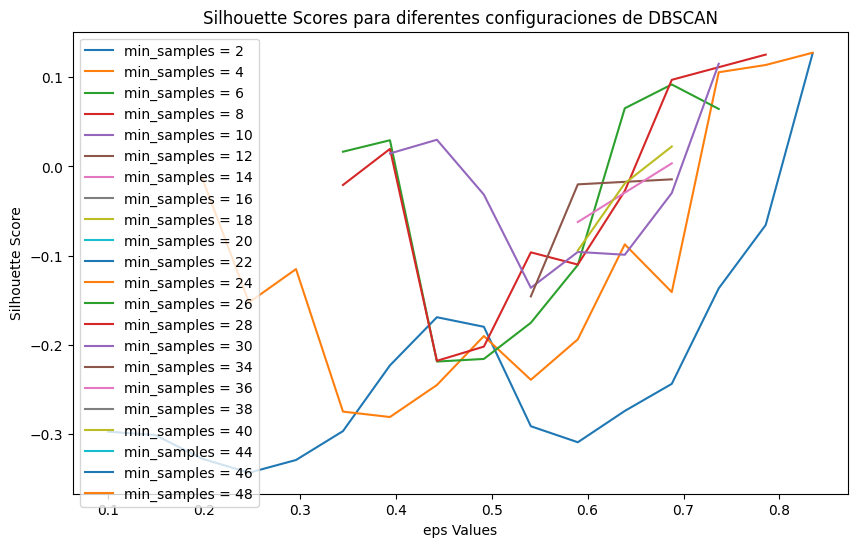

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import itertools

# Filtrar columnas "PC" del dataset (excluir columnas booleanas)
df_clustering_pca_filtered = df_clustering_pca.filter(regex='^PC')

# Definir la función de DBSCAN
def dbscan(X, eps_values, min_samples_values):
    best_silhouette = -1
    best_eps = None
    best_min_samples = None
    best_labels = None

    silhouette_scores = []

    # Iterar sobre valores de eps y min_samples (Grid Search Extenso)
    for eps, min_samples in itertools.product(eps_values, min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        # Filtrar los datos sin ruido y asegurarse de que haya al menos 2 clusters
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters >= 2:
            score = silhouette_score(X, labels)
            silhouette_scores.append((eps, min_samples, score))
            
            # Graficar solo si el puntaje de silueta es mayor a 0
            if score > 0:
                plot_silhouette(X, labels, f"eps={eps}, min_samples={min_samples}")

            if score > best_silhouette:
                best_silhouette = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

    print(f"Mejor configuración DBSCAN: eps = {best_eps}, min_samples = {best_min_samples}, Puntaje de Silueta = {best_silhouette}")
    return silhouette_scores

# Graficar el coeficiente de silueta para los clusters encontrados por DBSCAN
def plot_silhouette(X, labels, title):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        if i == -1:
            continue  # Ignorar ruido
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Gráfica de silueta para {title}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

# Graficar el coeficiente de silueta vs. configuración de DBSCAN
def plot_silhouette_vs_dbscan(silhouette_scores):
    eps_values, min_samples_values, scores = zip(*silhouette_scores)
    plt.figure(figsize=(10, 6))
    for min_samples in set(min_samples_values):
        eps_subset = [eps for eps, min_samples_val, score in silhouette_scores if min_samples_val == min_samples]
        scores_subset = [score for eps, min_samples_val, score in silhouette_scores if min_samples_val == min_samples]
        plt.plot(eps_subset, scores_subset, label=f'min_samples = {min_samples}')
    plt.xlabel('eps Values')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Scores para diferentes configuraciones de DBSCAN')
    plt.legend()
    plt.show()

# Ejecutar DBSCAN con múltiples configuraciones de `eps` y `min_samples`
eps_values = np.linspace(0.1, 2.5, 50)  # Ampliar la búsqueda con 50 valores entre 0.1 y 2.5
min_samples_values = range(2, 50, 2)    # Evaluar valores desde 2 hasta 50 con paso de 2

# Ejecutar la función DBSCAN
silhouette_scores = dbscan(df_clustering_pca_filtered, eps_values, min_samples_values)

# Graficar el coeficiente de silueta para diferentes configuraciones de DBSCAN
plot_silhouette_vs_dbscan(silhouette_scores)
